In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [5]:
df=pd.read_csv('CSV_FILES/removed.csv')
df

,Unnamed: 0,age,gender,item purchased,category,purchase amount (usd),location,size,color,season,review rating,subscription status,shipping type,discount applied,previous purchases,payment method,frequency of purchases
0,0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly
1,1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly
2,2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly
3,3,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly
4,4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3895,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,32,Venmo,Weekly
3896,3896,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,41,Bank Transfer,Bi-Weekly
3897,3897,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,24,Venmo,Quarterly
3898,3898,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,24,Venmo,Weekly


In [6]:
df['subscription status'].value_counts()

subscription status
No     2847
Yes    1053
Name: count, dtype: int64

In [7]:
(df['subscription status'].value_counts(normalize=True) * 100).round(2)

subscription status
No     73.0
Yes    27.0
Name: proportion, dtype: float64

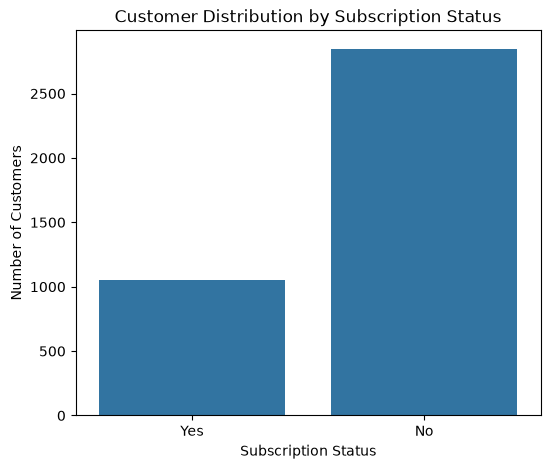

In [8]:
plt.figure(figsize=(6,5))

sns.countplot(
    x='subscription status',
    data=df
)

plt.title('Customer Distribution by Subscription Status')
plt.xlabel('Subscription Status')
plt.ylabel('Number of Customers')

plt.show()

In [9]:
subscription_avg = (
    df.groupby('subscription status')['purchase amount (usd)']
      .mean()
      .reset_index()
)

subscription_avg

,subscription status,purchase amount (usd)
0,No,59.865121
1,Yes,59.491928


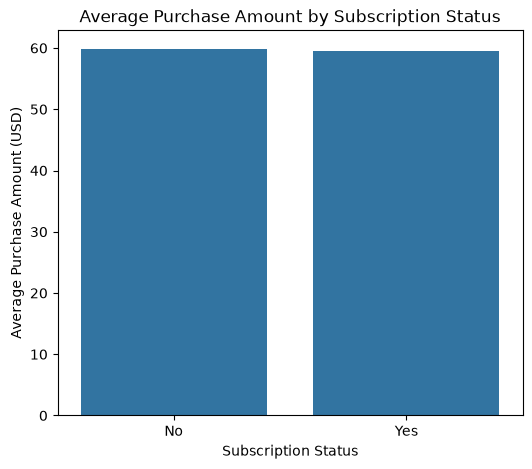

In [10]:
plt.figure(figsize=(6,5))

sns.barplot(
    x='subscription status',
    y='purchase amount (usd)',
    data=subscription_avg
)

plt.title('Average Purchase Amount by Subscription Status')
plt.xlabel('Subscription Status')
plt.ylabel('Average Purchase Amount (USD)')

plt.show()

In [11]:
subscription_revenue = (
    df.groupby('subscription status')['purchase amount (usd)']
      .sum()
      .reset_index()
)

subscription_revenue

,subscription status,purchase amount (usd)
0,No,170436
1,Yes,62645


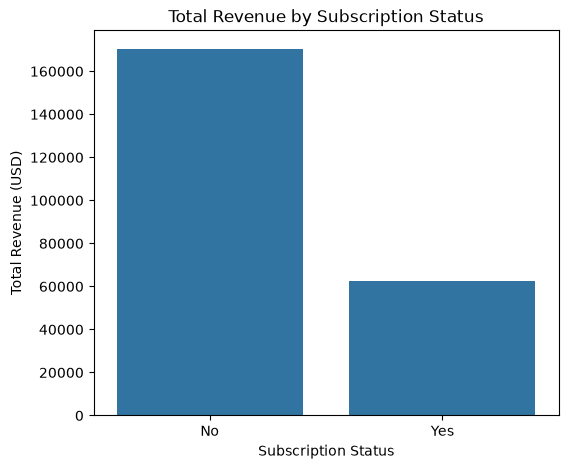

In [12]:
plt.figure(figsize=(6,5))

sns.barplot(
    x='subscription status',
    y='purchase amount (usd)',
    data=subscription_revenue
)

plt.title('Total Revenue by Subscription Status')
plt.xlabel('Subscription Status')
plt.ylabel('Total Revenue (USD)')

plt.show()

Although non-subscribers contribute the majority of total revenue, this is mainly due to their larger customer base. Subscribers and non-subscribers exhibit nearly identical average purchase amounts, suggesting that subscription status has little impact on spending per transaction.

In [13]:
df['discount applied'].value_counts()

discount applied
No     2223
Yes    1677
Name: count, dtype: int64

In [14]:
(df['discount applied'].value_counts(normalize=True)*100).round(2)

discount applied
No     57.0
Yes    43.0
Name: proportion, dtype: float64

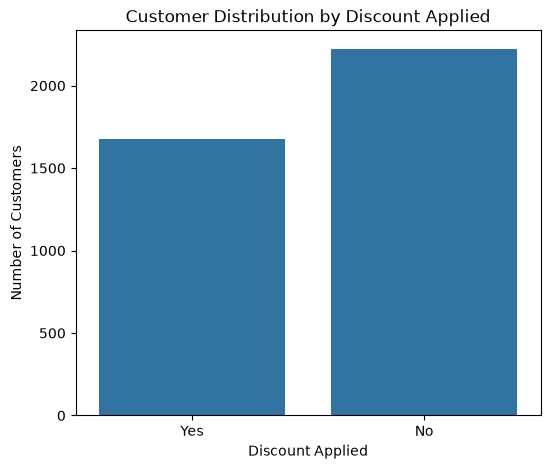

In [15]:
plt.figure(figsize=(6,5))

sns.countplot(
    x='discount applied',
    data=df
)

plt.title('Customer Distribution by Discount Applied')
plt.xlabel('Discount Applied')
plt.ylabel('Number of Customers')

plt.show()

In [16]:
discount_avg = (
    df.groupby('discount applied')['purchase amount (usd)']
      .mean()
      .reset_index()
)

discount_avg

,discount applied,purchase amount (usd)
0,No,60.130454
1,Yes,59.279070


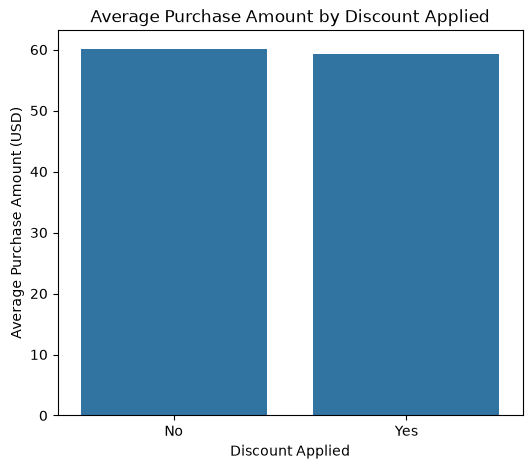

In [17]:
plt.figure(figsize=(6,5))

sns.barplot(
    x='discount applied',
    y='purchase amount (usd)',
    data=discount_avg
)

plt.title('Average Purchase Amount by Discount Applied')
plt.xlabel('Discount Applied')
plt.ylabel('Average Purchase Amount (USD)')

plt.show()

In [18]:
discount_revenue = (
    df.groupby('discount applied')['purchase amount (usd)']
      .sum()
      .reset_index()
)

discount_revenue

,discount applied,purchase amount (usd)
0,No,133670
1,Yes,99411


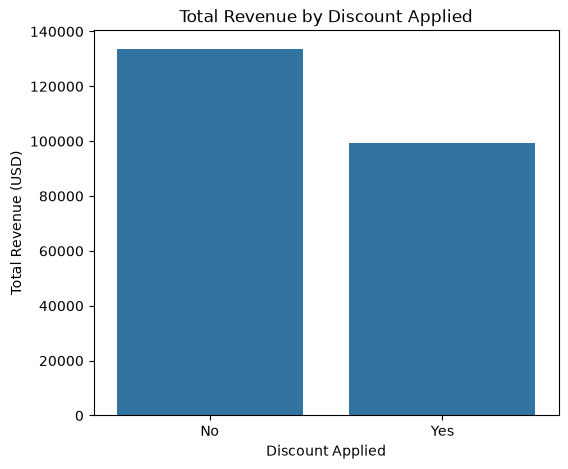

In [19]:
plt.figure(figsize=(6,5))

sns.barplot(
    x='discount applied',
    y='purchase amount (usd)',
    data=discount_revenue
)

plt.title('Total Revenue by Discount Applied')
plt.xlabel('Discount Applied')
plt.ylabel('Total Revenue (USD)')

plt.show()

Purchases made without discounts contribute a higher share of total revenue due to a larger number of transactions. However, the average purchase amount remains nearly the same regardless of whether a discount was applied, suggesting that discounts have little effect on the amount spent per purchase in this dataset.

In [20]:
df[['previous purchases', 'purchase amount (usd)']].corr()

,previous purchases,purchase amount (usd)
previous purchases,1.000000,0.008063
purchase amount (usd),0.008063,1.000000


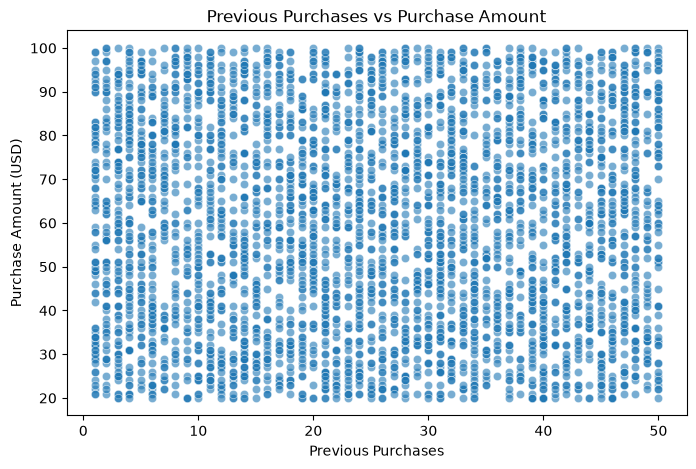

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='previous purchases',
    y='purchase amount (usd)',
    data=df,
    alpha=0.6
    
)

plt.title('Previous Purchases vs Purchase Amount')
plt.xlabel('Previous Purchases')
plt.ylabel('Purchase Amount (USD)')

plt.show()